In [10]:
import numpy as np
import matplotlib.pyplot as plt

In [11]:
cm_dsec = np.array([
    [1, 119],
    [3772, 439]
])

In [12]:
cm_framework = np.array([
    [118, 1],
    [3773, 438]
])

In [13]:
cms = [cm_dsec, cm_framework]
titles = ["Real DSEC Events", "Synthetic Events (Framework)"]

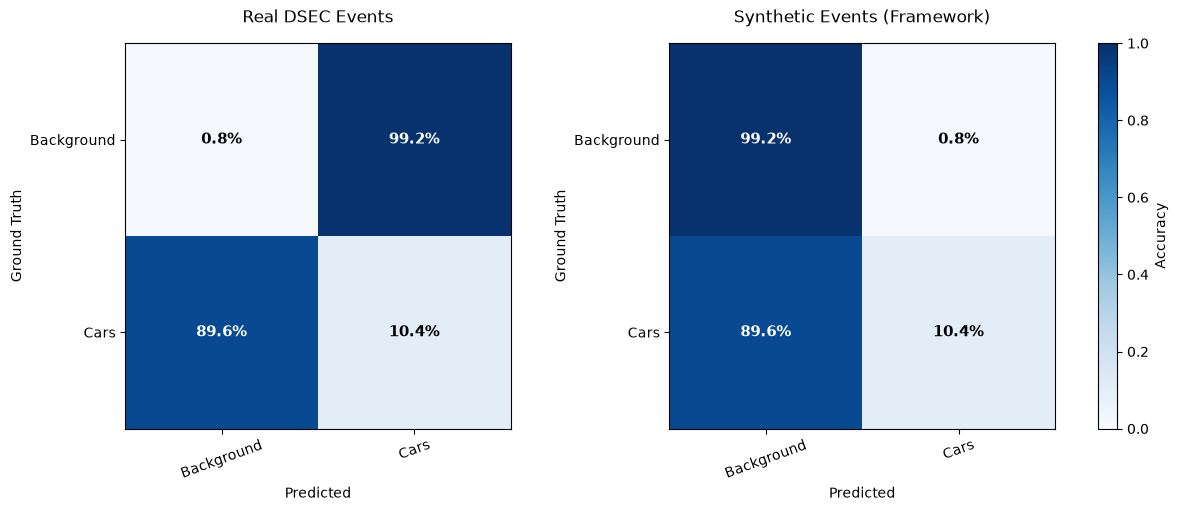

In [17]:
fig, axes = plt.subplots(
    1, 2,
    figsize=(12, 5),
    constrained_layout=True
)

for ax, cm, title in zip(axes, cms, titles):

    cm_norm = cm / cm.sum(axis=1, keepdims=True)

    im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)

    ax.set_title(title, pad=15)

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])

    ax.set_xticklabels(["Background", "Cars"], rotation=20)
    ax.set_yticklabels(["Background", "Cars"])

    ax.set_xlabel("Predicted")
    ax.set_ylabel("Ground Truth")

    for i in range(2):
        for j in range(2):
            ax.text(
                j,
                i,
                f"{cm_norm[i,j]*100:.1f}%",
                ha="center",
                va="center",
                color="white" if cm_norm[i,j] > 0.5 else "black",
                fontsize=11,
                fontweight="bold",
            )

cbar = fig.colorbar(
    im,
    ax=axes,
    fraction=0.04,
    pad=0.04
)

cbar.set_label("Accuracy")

plt.savefig(
    "confusion_matrix_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()